- 3 zhluky -> 5 zhlukov (prekryv);

In [11]:
from sklearn.decomposition import PCA
from helper_files.feature_selection_helper import *

# PCA

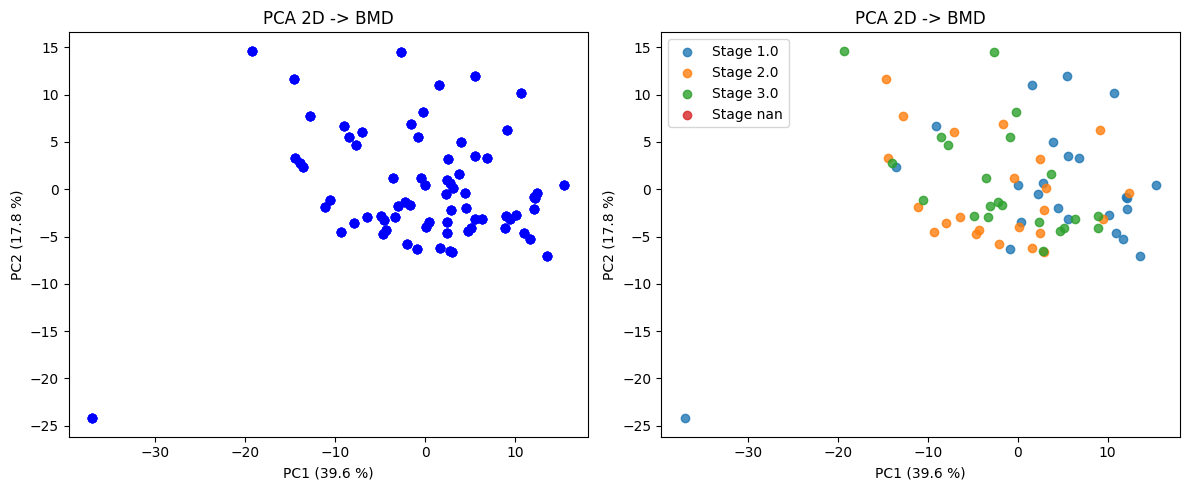

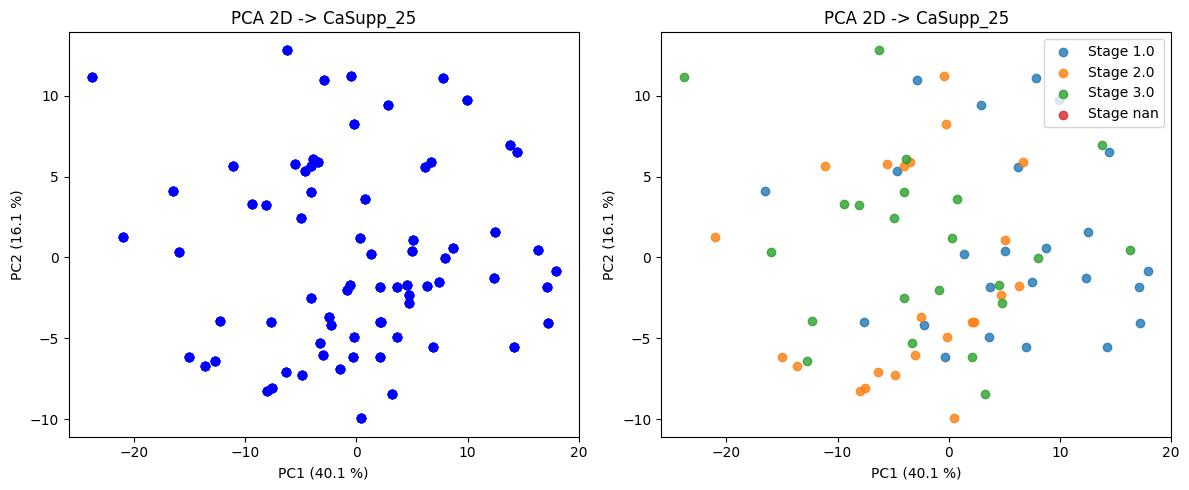

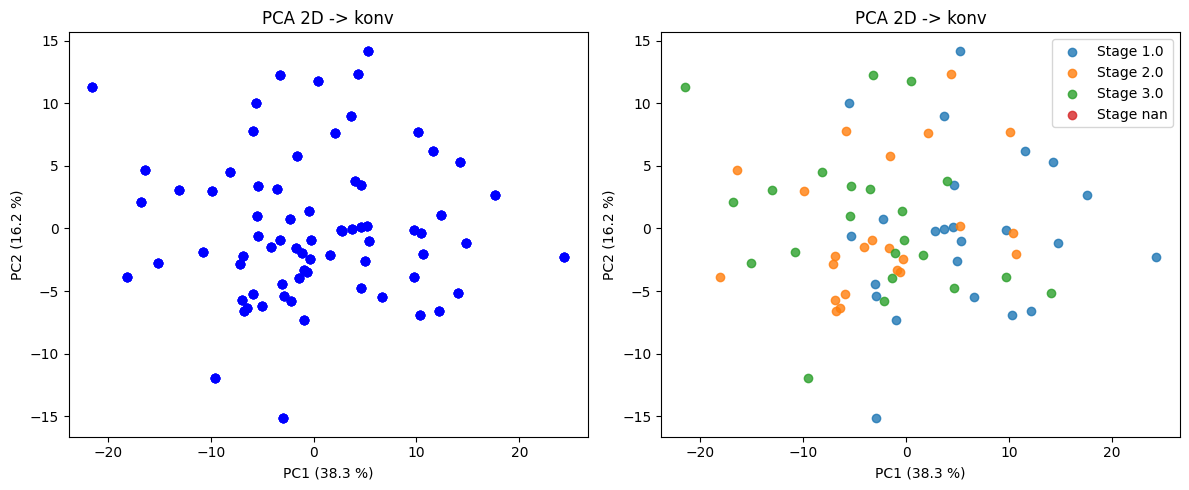

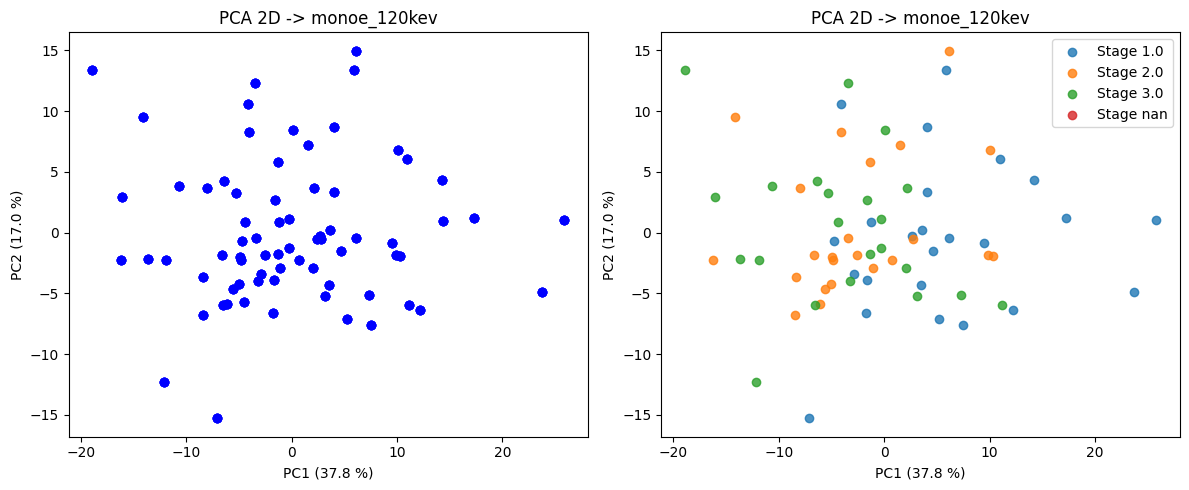

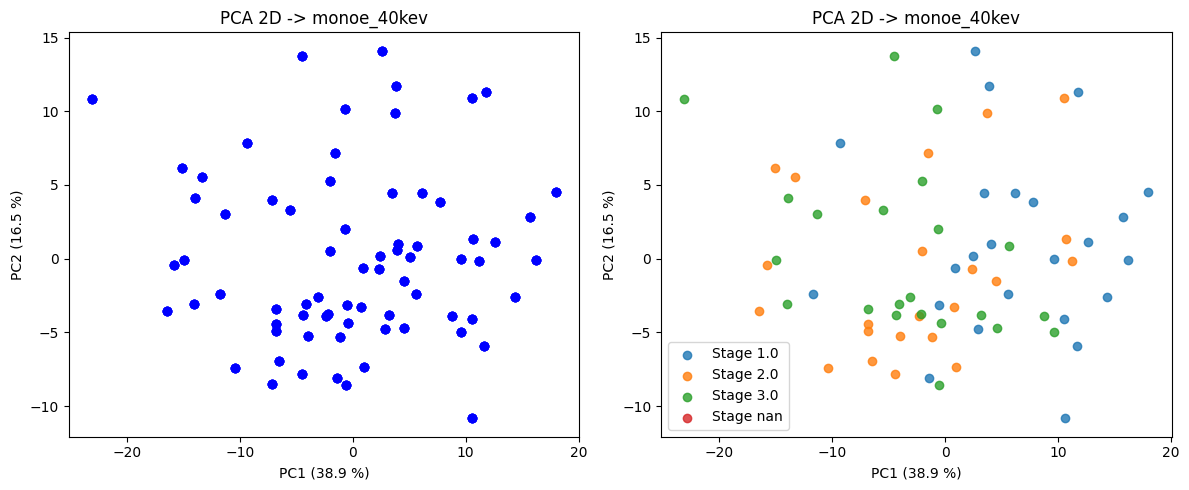

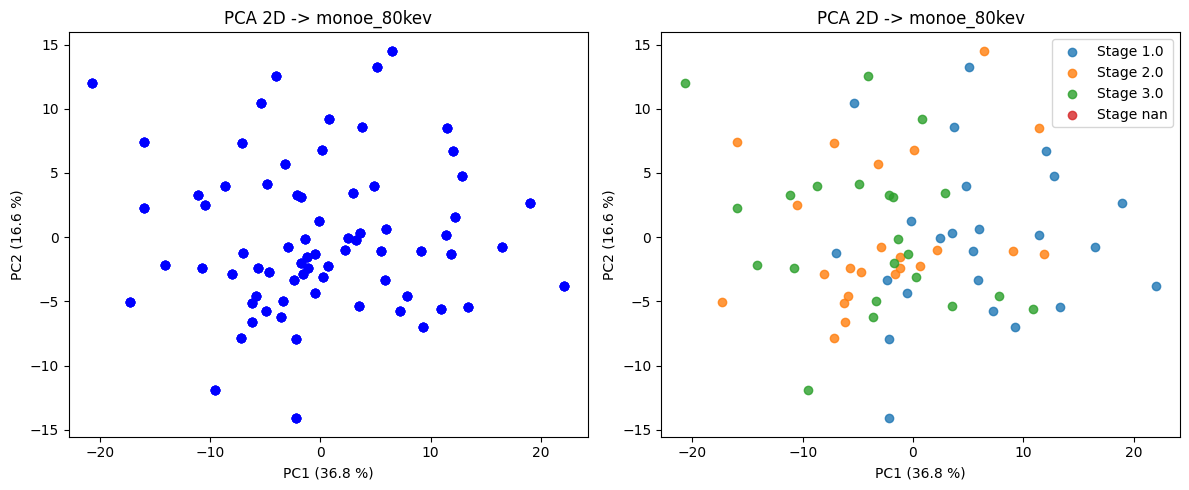

In [45]:
merged = merged_lesions_csv(r"E:\DATA_Myelomy")

clinical_df = df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})

for df_name, df in merged.items():

    df_patient = df.copy()
    df_merged = df_patient.merge(clinical_df[['Patient ID', 'Stage']], left_on='patient', right_on='Patient ID', how='left')

    df_features = df_merged.drop(columns=['patient', 'Stage', 'Patient ID'])
    stage = df_merged['Stage']

    df_scaled = StandardScaler().fit_transform(df_features)

    pca = PCA(n_components=2)
    df_pca = pca.fit_transform(df_scaled)

    plt.figure(figsize=(12, 5))
    for s in sorted(stage.unique()):
        idx = stage == s
        plt.subplot(122)
        plt.scatter(df_pca[idx, 0], df_pca[idx, 1], label=f"Stage {s}",alpha=0.8)
        plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f} %)")
        plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f} %)")
        plt.title(f"PCA 2D -> {df_name}")
        plt.legend()

        plt.subplot(121)
        plt.scatter(df_pca[:, 0], df_pca[:, 1], color="blue")
        plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f} %)")
        plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f} %)")
        plt.title(f"PCA 2D -> {df_name}")

    plt.tight_layout()
    plt.show()

# 2D clusters based on selected image features

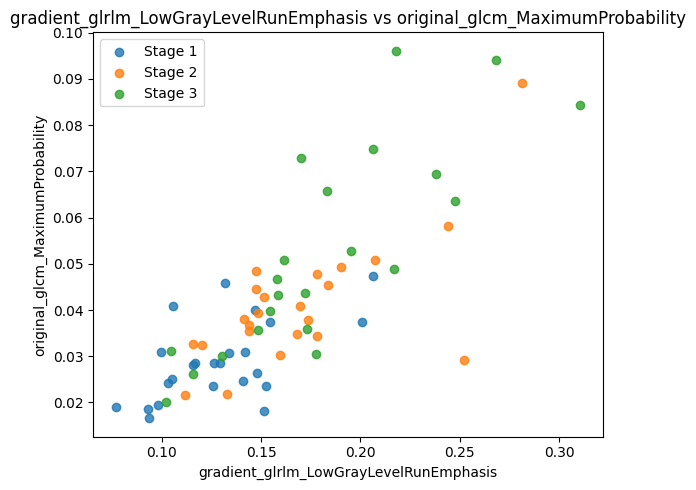

In [79]:
img_feature1 = 'gradient_glrlm_LowGrayLevelRunEmphasis'
img_feature2 = 'original_glcm_MaximumProbability'

df = pd.read_csv(r"E:\CSV\merged\merged_monoe_40kev_radiomics_spine_lesions_features.csv")
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})

df_merged = df.merge(clinical_df[['Patient ID', 'Stage']], left_on='patient', right_on='Patient ID', how='left')
df_merged = df_merged[df_merged['Stage'].notna()]
df_merged.drop(columns=['patient', 'Patient ID'], inplace=True)

plt.figure(figsize=(6,5))
for s in sorted(df_merged['Stage'].unique()):
    idx = df_merged['Stage'] == s
    plt.scatter(df_merged.loc[idx, img_feature1], df_merged.loc[idx, img_feature2], label=f"Stage {s}", alpha=0.8)

plt.xlabel(img_feature1)
plt.ylabel(img_feature2)
plt.title(f"{img_feature1} vs {img_feature2}")
plt.legend()
plt.tight_layout()
plt.show()

# 2D clusters based on selected clinical features

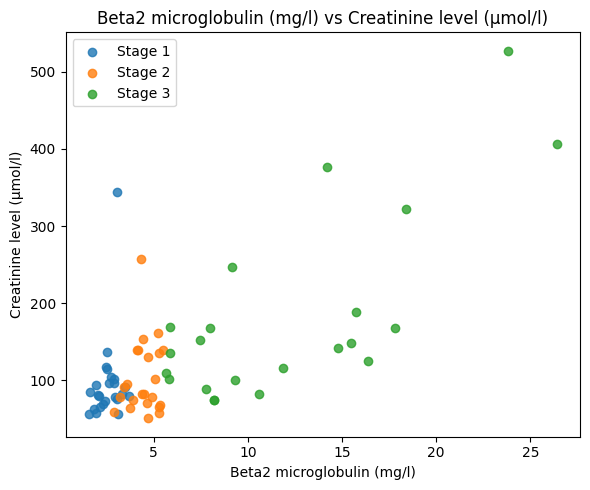

In [75]:
feature1 = 'Beta2 microglobulin (mg/l)'
feature2 = 'Creatinine level (µmol/l)'

clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})

clinical_df = clinical_df[clinical_df['Stage'].notna()]
clinical_df.drop(columns=['Patient ID'], inplace=True)

plt.figure(figsize=(6,5))
for s in sorted(clinical_df['Stage'].unique()):
    idx = clinical_df['Stage'] == s
    plt.scatter(clinical_df.loc[idx, feature1], clinical_df.loc[idx, feature2], label=f"Stage {s}", alpha=0.8)

plt.xlabel(feature1)
plt.ylabel(feature2)
plt.title(f"{feature1} vs {feature2}")
plt.legend()
plt.tight_layout()
plt.show()

# PCA from selected image features

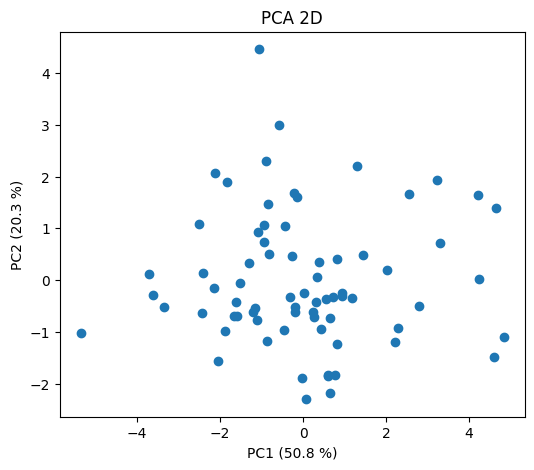

In [6]:
image_features = ["original_firstorder_Kurtosis", "original_glcm_MaximumProbability", "original_glcm_DifferenceAverage", "original_glcm_Idm",
                  "original_glcm_Id", "original_firstorder_Skewness", "gradient_glcm_Imc2", "gradient_glcm_Correlation"]

df = pd.read_csv(r"E:\CSV\merged\merged_monoe_40kev_radiomics_spine_lesions_features.csv").filter(items=image_features)
df_scaled = StandardScaler().fit_transform(df)

pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(df_pca[:, 0], df_pca[:, 1])
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f} %)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f} %)")
plt.title(f"PCA 2D")

plt.show()

# Try to find the best clusters as possible

Hopkins statistic

- Hodnota ~0.5 → náhodné dáta (žiadne zhluky)
- Hodnota <<0.5 → zhluky prítomné

In [53]:
# HOPKINS STATISTIC
from pyclustertend import hopkins
import pandas as pd

df = pd.read_csv(r"E:\CSV\merged\merged_monoe_40kev_radiomics_spine_lesions_features.csv").drop(columns=['patient'])
X = StandardScaler().fit_transform(df)
h = hopkins(X, X.shape[0])
print("Hopkins statistic: ", h)

Hopkins statistic:  0.25532138486615313


In [55]:
from itertools import combinations
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

df = pd.read_csv(r"E:\CSV\merged\merged_monoe_40kev_radiomics_spine_lesions_features.csv").drop(columns=['patient'])
features = df.columns.tolist()
best_score = -1
best_pair = None

for feat1, feat2 in combinations(features, 2):
    X_pair = df[[feat1, feat2]].values
    X_scaled = StandardScaler().fit_transform(X_pair)

    kmeans = KMeans(n_clusters=3, random_state=42).fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)

    if score > best_score:
        best_score = score
        best_pair = (feat1, feat2)

print("Best features pair:", best_pair)
print("Silhouette score:", best_score)

Best features pair: ('gradient_glszm_LargeAreaLowGrayLevelEmphasis', 'gradient_glszm_ZoneVariance')
Silhouette score: 0.926674481436329


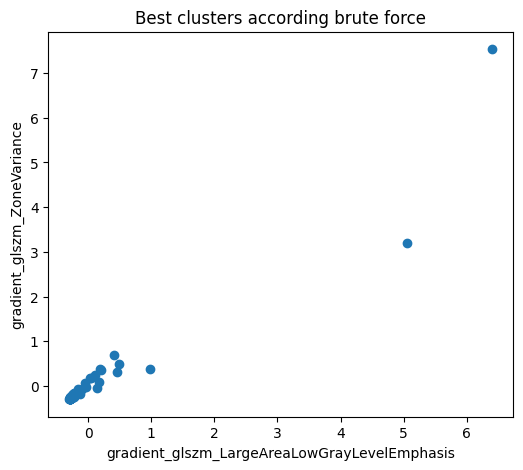

In [56]:
best_feats = list(best_pair)
X_best = df[best_feats]
X_scaled = StandardScaler().fit_transform(X_best)

plt.figure(figsize=(6,5))
plt.scatter(X_scaled[:,0], X_scaled[:,1])
plt.xlabel(best_feats[0])
plt.ylabel(best_feats[1])
plt.title("Best clusters according brute force")
plt.show()

# UMAP

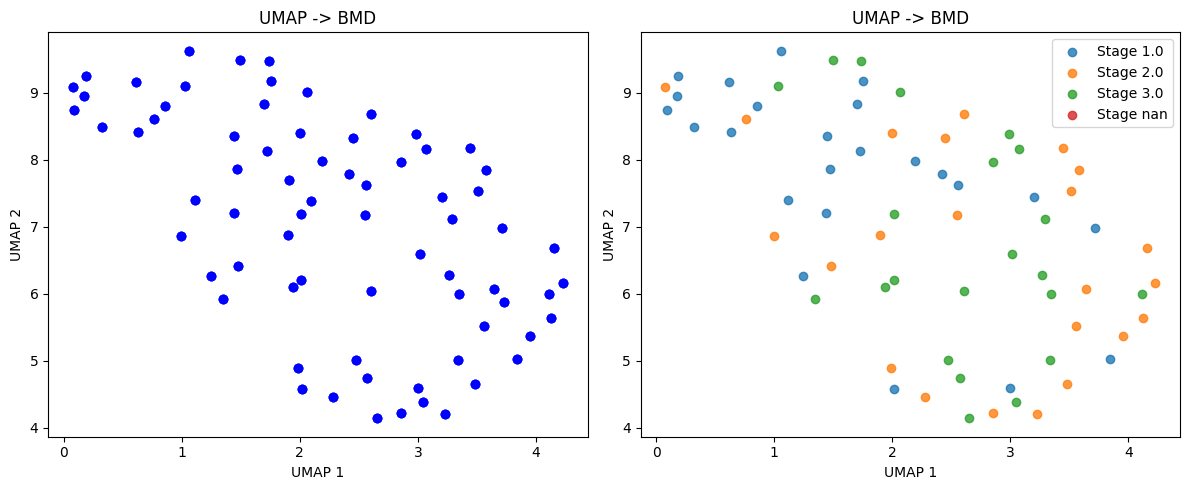

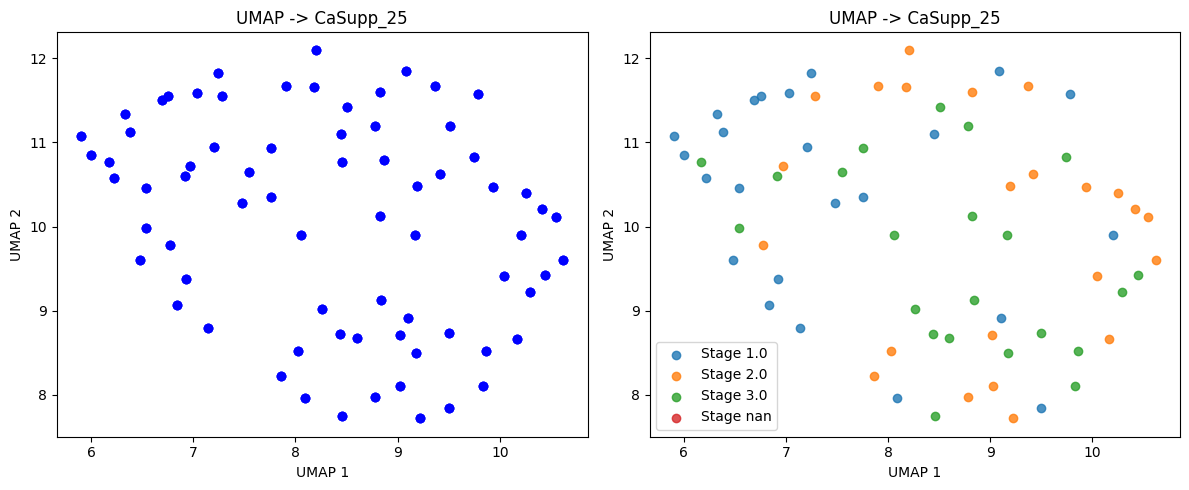

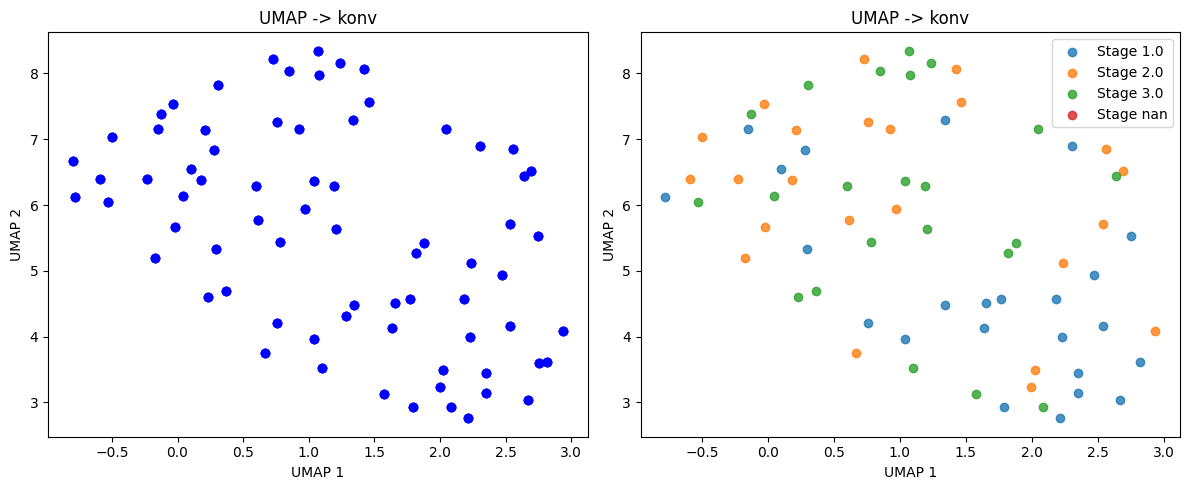

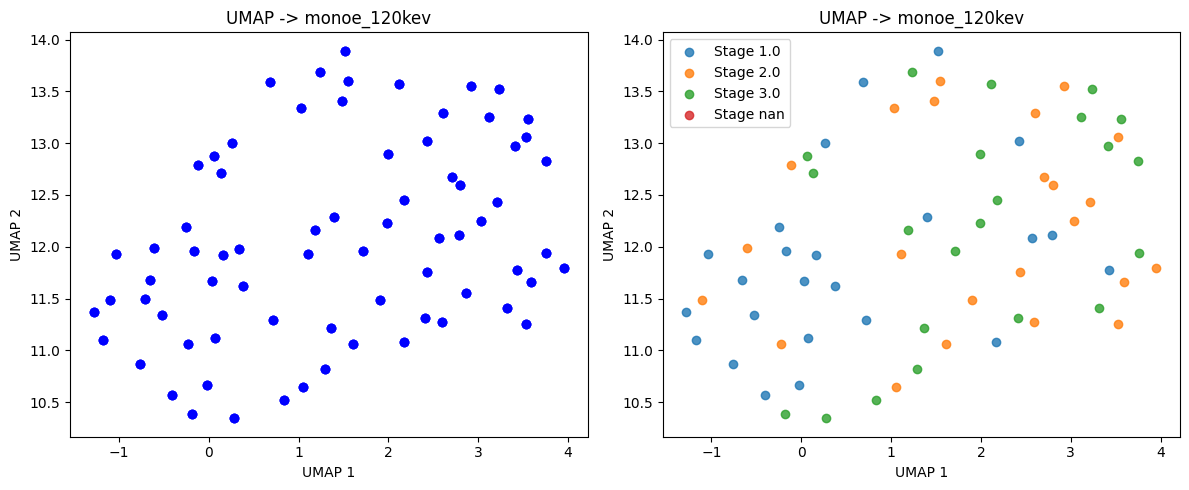

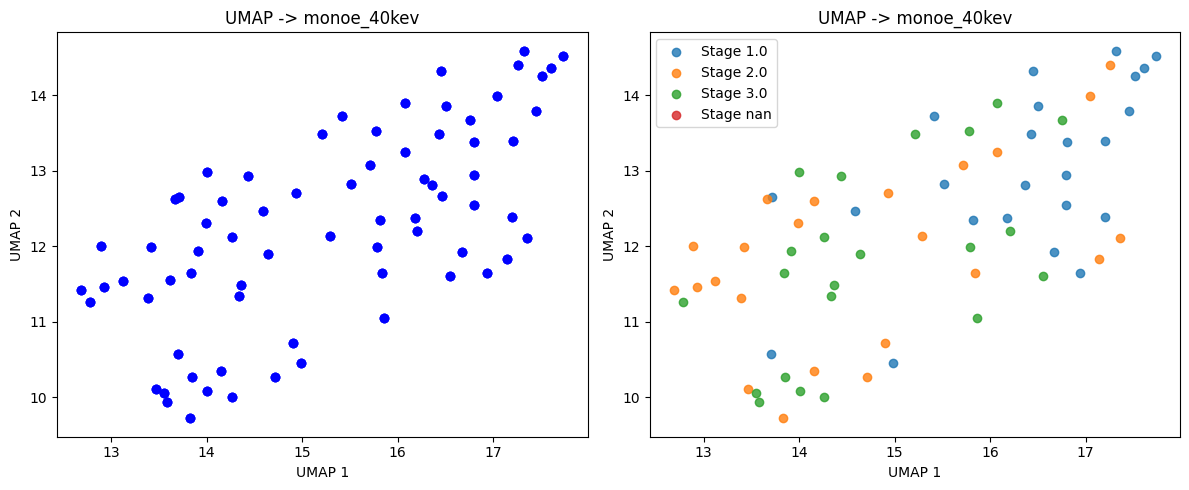

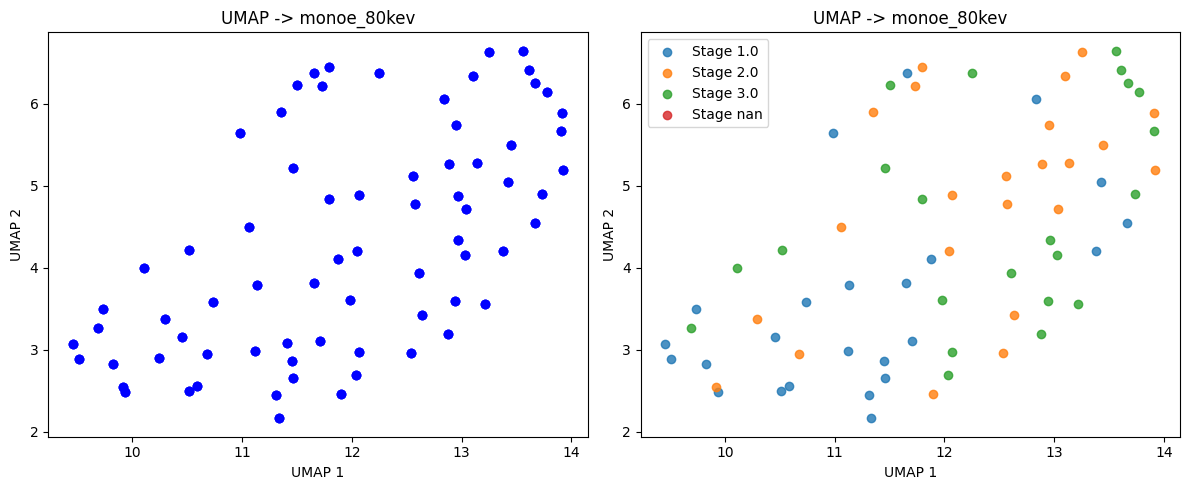

In [50]:
import umap.umap_ as umap

merged = merged_lesions_csv(r"E:\DATA_Myelomy")

clinical_df = df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})

for df_name, df in merged.items():

    df_patient = df.copy()
    df_merged = df_patient.merge(clinical_df[['Patient ID', 'Stage']], left_on='patient', right_on='Patient ID', how='left')

    df_features = df_merged.drop(columns=['patient', 'Stage', 'Patient ID'])
    stage = df_merged['Stage']

    df_scaled = StandardScaler().fit_transform(df_features)

    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
    X_umap = reducer.fit_transform(df_scaled)

    plt.figure(figsize=(12, 5))
    for s in sorted(stage.unique()):
        idx = stage == s
        plt.subplot(122)
        plt.scatter(X_umap[idx, 0], X_umap[idx, 1], label=f"Stage {s}", alpha=0.8)
        plt.xlabel("UMAP 1")
        plt.ylabel("UMAP 2")
        plt.title(f"UMAP -> {df_name}")
        plt.legend()

        plt.subplot(121)
        plt.scatter(X_umap[:, 0], X_umap[:, 1], color='blue', alpha=0.7)
        plt.xlabel("UMAP 1")
        plt.ylabel("UMAP 2")
        plt.title(f"UMAP -> {df_name}")

    plt.tight_layout()
    plt.show()